In [28]:
!pip install deepface opencv-python pillow matplotlib torchvision


In [29]:
import os
import cv2
import numpy as np
from PIL import Image
from deepface import DeepFace
from matplotlib import pyplot as plt
from google.colab import files
import zipfile
import glob
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import torch.nn.functional as F


In [30]:
## Load the datset


def upload_image_dataset():
    print(" Please upload a ZIP file containing your face images (.jpg)")
    uploaded = files.upload()
    for file_name in uploaded.keys():
        if file_name.endswith('.zip'):
            with zipfile.ZipFile(file_name, 'r') as zip_ref:
                zip_ref.extractall("/content/faces_dataset")
    print(" Dataset extracted to: /content/faces_dataset")
    image_paths = glob.glob("/content/faces_dataset/**/*.jpg", recursive=True)
    print(f"Total images found: {len(image_paths)}")
    return image_paths

image_paths = upload_image_dataset()


 Please upload a ZIP file containing your face images (.jpg)


Saving original images (2).zip to original images (2) (1).zip
 Dataset extracted to: /content/faces_dataset
Total images found: 2667


In [31]:
### Face Detection and Shirt Color Detection


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_face_and_shirt(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) == 0:
        return None, None, None
    (x, y, w, h) = faces[0]
    face_img = img[y:y+h, x:x+w]
    shirt_region = img[y+h:y+2*h, x:x+w] if y+2*h < img.shape[0] else None
    return img, face_img, shirt_region

def get_shirt_color(bgr_crop):
    if bgr_crop is None:
        return "Unknown"
    avg_color = bgr_crop.mean(axis=0).mean(axis=0)
    b, g, r = int(avg_color[0]), int(avg_color[1]), int(avg_color[2])
    return f"RGB({r},{g},{b})"


In [32]:
### Gender Detection using Deepface

def get_gender_deepface(face_img):
    try:
        rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
        result = DeepFace.analyze(rgb, actions=['gender'], enforce_detection=False)
        return result[0]['dominant_gender'].capitalize()
    except Exception as e:
        return "Unknown"


In [34]:
### Glasses Detection using resnet model


import torch
import torch.nn as nn
from torchvision import models

class GlassesResNet(nn.Module):
    def __init__(self):
        super(GlassesResNet, self).__init__()
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)  #

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
glasses_model = GlassesResNet().to(device)


In [35]:
### Add the path path od resnet model

import torchvision.models as models

glasses_model = models.resnet18()
glasses_model.load_state_dict(torch.load("/content/resnet18-f37072fd.pth", map_location=device))
glasses_model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [37]:
### Assuming binary classification: glasses/no-glasses

glasses_model.fc = nn.Linear(glasses_model.fc.in_features, 2)



 Image: /content/faces_dataset/original images/images/PetN_02266_m_20_o_fr_nc_no_2015_1_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: Yes
 3- Shirt Color: Unknown


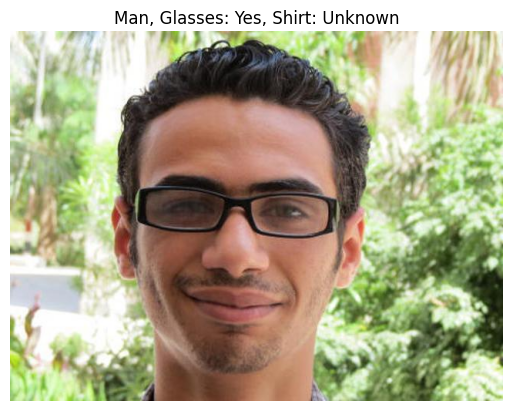


 Image: /content/faces_dataset/original images/images/MahM_01144_m_26_i_fr_nc_hp_2016_2_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: No
 3- Shirt Color: RGB(103,107,105)


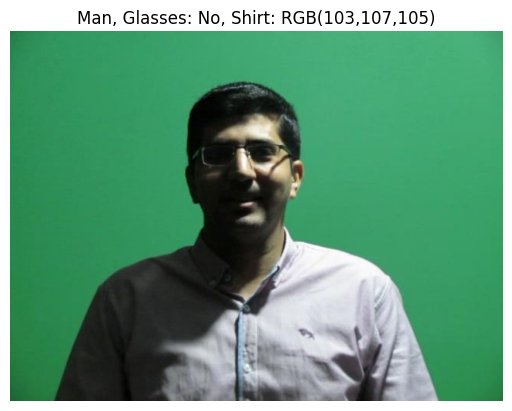


 Image: /content/faces_dataset/original images/images/MahA_00955_m_28_i_fr_nc_sd_2016_2_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: Yes
 3- Shirt Color: Unknown


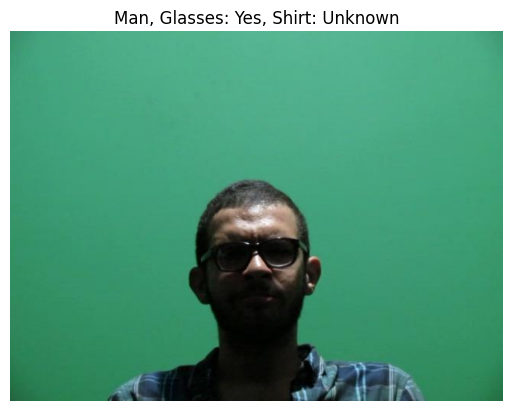


 Image: /content/faces_dataset/original images/images/OliA_02159_f_20_i_fr_nc_hp_2016_2_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: Yes
 3- Shirt Color: RGB(4,5,4)


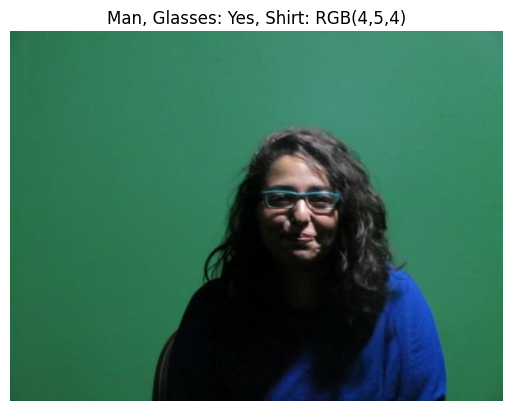


 Image: /content/faces_dataset/original images/images/MazR_01347_m_24_o_nf_nc_hp_2015_1_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: Yes
 3- Shirt Color: Unknown


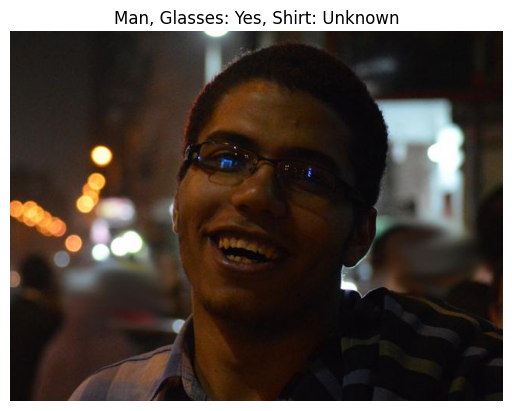


 Image: /content/faces_dataset/original images/images/MarH_01300_f_31_o_fr_nc_hp_2016_1_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: No
 3- Shirt Color: RGB(68,60,68)


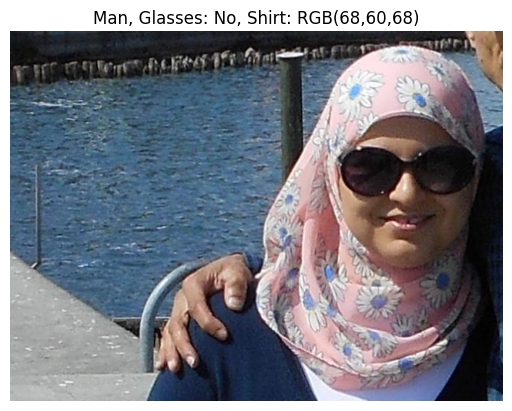


 Image: /content/faces_dataset/original images/images/MeiH_01359_f_20_i_fr_cr_no_2015_1_e0_nl_o.jpg
 1- Gender: Woman
 2- Wearing Glasses: Yes
 3- Shirt Color: Unknown


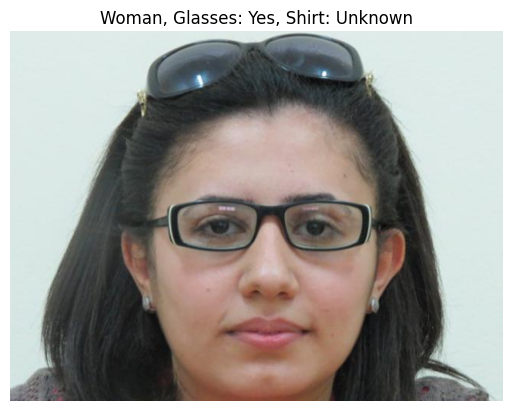


 Image: /content/faces_dataset/original images/images/SarE_02357_f_22_i_nf_nc_hp_2016_2_e0_nl_o.jpg
 No face detected.

 Image: /content/faces_dataset/original images/images/AbdA_00079_m_31_i_fr_nc_no_2016_2_e0_nl_o.jpg
 No face detected.

 Image: /content/faces_dataset/original images/images/MahM_01195_m_26_i_fr_nc_no_2016_2_e0_nl_o.jpg
 1- Gender: Man
 2- Wearing Glasses: Yes
 3- Shirt Color: RGB(30,37,33)


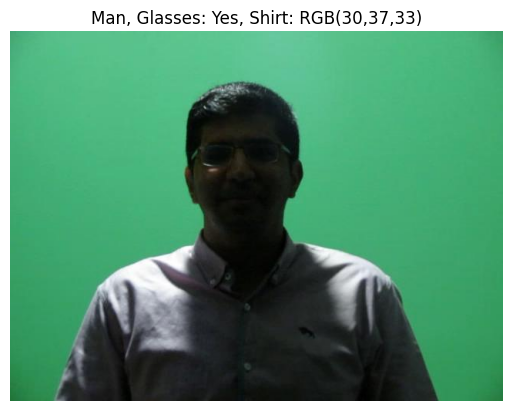

In [41]:
def predict_glasses(face_img):
    """
    Predicts whether a person in a face image is wearing glasses.

    Args:
        face_img (numpy.ndarray): Cropped face image (BGR format).

    Returns:
        str: "Yes" if glasses are predicted, "No" otherwise.
    """
    if face_img is None or face_img.size == 0:
        return "Unknown"

    ### Convert BGR to RGB and to PIL Image
    rgb_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb_img)

    ### Define the same transformation used during training
    transform = transforms.Compose([
        ### Resize to model's input size
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
         ### ImageNet mean/std
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    ### Apply transform and add batch dimension
    input_tensor = transform(pil_img).unsqueeze(0).to(device)

    ### Perform inference
    with torch.no_grad():
        output = glasses_model(input_tensor)
        ### Get the predicted class (index 0 or 1)
        _, predicted_class = torch.max(output, 1)

    ### Assuming class 0 is 'no glasses' and class 1 is 'glasses' (adjust if necessary)
    return "Yes" if predicted_class.item() == 1 else "No"

### Rest of your code
for image_path in image_paths[:10]:
    print(f"\n Image: {image_path}")
    original, face_crop, shirt_crop = detect_face_and_shirt(image_path)

    if face_crop is None:
        print(" No face detected.")
        continue

    gender = get_gender_deepface(face_crop)
    ### Call the newly defined predict_glasses function
    glasses = predict_glasses(face_crop)
    shirt_color = get_shirt_color(shirt_crop)

    print(f" 1- Gender: {gender}")
    print(f" 2- Wearing Glasses: {glasses}")
    print(f" 3- Shirt Color: {shirt_color}")

    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"{gender}, Glasses: {glasses}, Shirt: {shirt_color}")
    plt.show()
